In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Literal

In [2]:
class QuadState(TypedDict):
    a: int
    b: int
    c: int

    equation: str
    discriminant: float
    result: str

In [3]:
def show_equation(state: QuadState) -> QuadState:

    equation = f"{state['a']}x2 + {state['b']}x + {state['c']} = 0"

    return {'equation': equation}

In [4]:
def calculate_discriminant(state: QuadState) -> QuadState:

    discriminant = state['b']**2 - 4*state['a'] * state['c']

    return {'discriminant': discriminant}

In [12]:
def real_roots(state: QuadState) -> QuadState:

    root1 = (-state['b'] + state['discriminant']**0.5) / (2*state['a'])
    root2 = (-state['b'] - state['discriminant']**0.5) / (2*state['a'])

    result = f"Two real roots: {root1} and {root2}"

    return {'result': result}

In [13]:
def one_root(state: QuadState) -> QuadState:

    root = -state['b'] / (2*state['a'])

    result = f"One real root: {root}"

    return {'result': result}

In [14]:
def imaginary_roots(state: QuadState) -> QuadState:

    real_part = -state['b'] / (2*state['a'])
    imaginary_part = abs(state['discriminant'])**0.5 / (2*state['a'])

    result = f"Two imaginary roots: {real_part} + {imaginary_part}i and {real_part} - {imaginary_part}i"

    return {'result': result}

In [23]:
def check_discriminant(state: QuadState) -> Literal["real_roots", "one_root", "imaginary_roots"]:

    if state['discriminant'] > 0:
        return "real_roots"
    elif state['discriminant'] == 0:
        return "one_root"
    else:
        return "imaginary_roots"

In [24]:
graph = StateGraph(QuadState)

graph.add_node('show_equation', show_equation)
graph.add_node('calculate_discriminant', calculate_discriminant)
graph.add_node('real_roots', real_roots)
graph.add_node('one_root', one_root)
graph.add_node('imaginary_roots', imaginary_roots)

graph.add_edge(START, 'show_equation')
graph.add_edge('show_equation', 'calculate_discriminant')

graph.add_conditional_edges('calculate_discriminant', check_discriminant)
graph.add_edge('real_roots', END)
graph.add_edge('one_root', END)
graph.add_edge('imaginary_roots', END)

workflow = graph.compile()

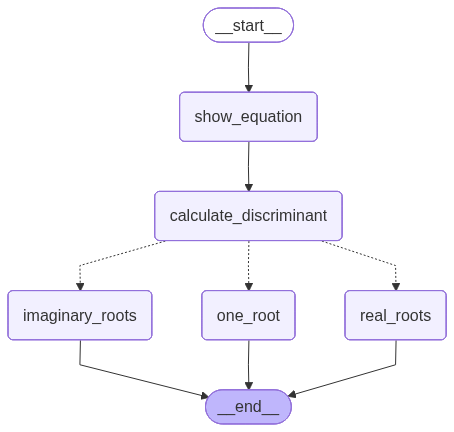

In [25]:
workflow

In [33]:
initial_state = {
    'a': 1,
    'b': -3,
    'c': 8
}

final_state = workflow.invoke(initial_state)


In [34]:
print(final_state)

{'a': 1, 'b': -3, 'c': 8, 'equation': '1x2 + -3x + 8 = 0', 'discriminant': -23, 'result': 'Two imaginary roots: 1.5 + 2.3979157616563596i and 1.5 - 2.3979157616563596i'}
